TASK 1 - Data Import & Setup

In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1.Import CSV using Pandas
df = pd.read_csv("/content/social_media_engagement_5000.csv")
df.head()
df.tail()
df.shape
df.columns
# 2. Check data types
df.info()
df.dtypes
# 3. Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')
df['posted_at'].dtype
# 4. Basic NumPy array operations
arr = np.array([10, 20, 30, 40, 50])

print("Sum:", np.sum(arr))
print("Mean:", np.mean(arr))
print("Maximum:", np.max(arr))
print("Minimum:", np.min(arr))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


TASK 2 -  Data Cleaning

In [262]:
# Cleaning Missing Data

## 1.Detect missing values (isnull(), isna())
print("Missing values before cleaning:")
print(df.isnull().sum())
## 2. Handle missing numerical values using median
numeric_columns = ['age', 'likes', 'comments', 'shares']
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())
## 3. Handle missing categorical values using mode
categorical_columns = ['gender', 'sentiment']
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Duplicate Handling

## 4. Identify and remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Data Formatting

## 5. Standardize gender labels
df['gender'] = df['gender'].str.strip().str.title()
## 6. Standardize categorical columns
text_columns = ['country', 'post_type', 'post_category', 'device_type']

for column in text_columns:
    df[column] = df[column].str.strip().str.lower()
## 7. Clean sentiment labels
df['sentiment'] = df['sentiment'].str.strip().str.lower()
## 8. Correct unrealistic values in likes, comments, shares
print("Negative likes:", (df['likes'] < 0).sum())
print("Negative comments:", (df['comments'] < 0).sum())
print("Negative shares:", (df['shares'] < 0).sum())

# Feature Cleaning

## 9. Extract hashtag count
df['hashtag_count'] = df['hashtags'].str.split().str.len()
#  Verify
print("Missing values after cleaning:")
print(df.isnull().sum())
print("Missing values using isna():")
print(df.isna().sum())
print("Cleaned dataset shape:", df.shape)
df.head()

## Demonstration of dropna()
df_dropna = df.dropna()

print("Original df shape:", df.shape)
print("Shape after dropna():", df_dropna.shape)

## Demonstration of forward fill and backward fill

df_ffill = df.ffill()
df_bfill = df.bfill()

print("Original missing values:", df.isnull().sum().sum())
print("Missing values after forward fill:", df_ffill.isnull().sum().sum())
print("Missing values after backward fill:", df_bfill.isnull().sum().sum())

Missing values before cleaning:
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
Duplicate rows: 0
Negative likes: 0
Negative comments: 0
Negative shares: 0
Missing values after cleaning:
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags          

TASK 3 - Data Exploration using Pandas

In [263]:
df.head()
df.tail()
print("Dataset Shape:\n", df.shape)

print("\nColumn Names:\n")
df.columns

df.info()
#  Check data types
print("\nData Types:\n")
df.dtypes

# 7. Descriptive statistics
df.describe()

Dataset Shape:
 (5000, 20)

Column Names:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   i

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [264]:
# Categorical distributions
print("\nGender Distribution:\n")
print(df['gender'].value_counts())
print("\nPost Type Distribution:\n")
print(df['post_type'].value_counts())
print("\nPost Category Distribution:\n")
print(df['post_category'].value_counts())
print("\nDevice Type Distribution:\n")
print(df['device_type'].value_counts())
print("\nSentiment Distribution:\n")
print(df['sentiment'].value_counts())


Gender Distribution:

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Post Type Distribution:

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Post Category Distribution:

post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

Device Type Distribution:

device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

Sentiment Distribution:

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [265]:
# Unique values
print("\nUnique Gender Values:\n")
print(df['gender'].unique())

print("\nUnique Post Types:\n")
print(df['post_type'].unique())

print("\nUnique Post Categories:\n")
print(df['post_category'].unique())

print("\nUnique Device Types:\n")
print(df['device_type'].unique())

print("\nUnique Sentiments:\n")
print(df['sentiment'].unique())


Unique Gender Values:

['Female' 'Male' 'Other']

Unique Post Types:

['image' 'reel' 'text' 'video']

Unique Post Categories:

['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']

Unique Device Types:

['mobile' 'tablet' 'desktop']

Unique Sentiments:

['negative' 'positive' 'neutral']


In [266]:
# Number of unique values
print("\nNumber of Unique Gender Values:", df['gender'].nunique())
print("Number of Unique Post Types:", df['post_type'].nunique())
print("Number of Unique Post Categories:", df['post_category'].nunique())
print("Number of Unique Device Types:", df['device_type'].nunique())
print("Number of Unique Sentiments:", df['sentiment'].nunique())


Number of Unique Gender Values: 3
Number of Unique Post Types: 4
Number of Unique Post Categories: 8
Number of Unique Device Types: 3
Number of Unique Sentiments: 3


In [267]:
# Correlation matrix
print("\nCorrelation Matrix:")
df.corr(numeric_only=True)


Correlation Matrix:


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,0.004058,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,-0.000079,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.025208,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,-0.016200,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,-0.012398,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.007025,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,0.012326,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,0.008317,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,-0.017808,0.002292,0.008802
is_verified,0.004058,-0.000079,0.025208,-0.016200,-0.012398,0.007025,0.012326,0.008317,-0.017808,1.000000,0.005528,0.001396


In [268]:
# Groupby summaries
print("\nAverage Likes by Post Type:\n")
print(df.groupby('post_type')['likes'].mean())

print("\nAverage Engagement Rate by Post Type:\n")
print(df.groupby('post_type')['engagement_rate'].mean())

print("\nAverage Likes by Post Category:\n")
print(df.groupby('post_category')['likes'].mean())

print("\nAverage Engagement Rate by Sentiment:\n")
print(df.groupby('sentiment')['engagement_rate'].mean())

print("\nAverage Watch Time by Device:\n")
print(df.groupby('device_type')['watch_time_sec'].mean())


Average Likes by Post Type:

post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64

Average Engagement Rate by Post Type:

post_type
image    0.895646
reel     0.783047
text     1.064549
video    1.122365
Name: engagement_rate, dtype: float64

Average Likes by Post Category:

post_category
education    10126.487322
fashion       9843.356902
fitness       9914.602222
food         10225.522766
lifestyle    10180.559308
music        10205.749606
tech         10171.571429
travel       10196.304167
Name: likes, dtype: float64

Average Engagement Rate by Sentiment:

sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64

Average Watch Time by Device:

device_type
desktop    3974.792521
mobile     4087.830760
tablet     3979.736429
Name: watch_time_sec, dtype: float64


TASK 4 - Data Wrangling

In [269]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
print("Engagement Score")
df[['likes', 'comments', 'shares', 'engagement_score']].head()

Engagement Score


,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


In [270]:
print("Hashtag Count")
df[['hashtags', 'hashtag_count']].head()

Hashtag Count


,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


In [235]:
import numpy as np

In [271]:
df['log_likes'] = np.log1p(df['likes'])
print("Log-Transformed Likes")
df[['likes', 'log_likes']].head()

Log-Transformed Likes


,likes,log_likes
0,7011.0,8.855378
1,11750.0,9.371694
2,4862.0,8.489411
3,5350.0,8.585039
4,12682.0,9.448018


In [272]:
df.groupby('post_type')['engagement_score'].mean()

,engagement_score
post_type,
image,12649.390537
reel,12524.031567
text,12613.243775
video,12664.594286


In [273]:
df.groupby('country')['engagement_score'].mean()

,engagement_score
country,
australia,12809.621704
brazil,12385.983135
canada,12605.894737
france,12903.384073
germany,12635.664286
india,12492.701869
japan,12578.648305
uae,12757.777336
uk,12384.374239


In [274]:
df.groupby('sentiment')['engagement_score'].mean()

,engagement_score
sentiment,
negative,12731.498958
neutral,12448.163720
positive,12665.799443


TASK 5 -  Statistical Analysis

In [275]:
stats_columns = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

In [276]:
# Calculate descriptive statistics
statistics_summary=pd.DataFrame({
    'Mean':df[stats_columns].mean(),
    'Median':df[stats_columns].median(),
    'Mode':df[stats_columns].mode().iloc[0],
    'Standard Deviation':df[stats_columns].std(),
    'Variance':df[stats_columns].var(),
    '25th Percentile':df[stats_columns].quantile(0.25),
    '50th Percentile':df[stats_columns].quantile(0.50),
    '75th Percentile':df[stats_columns].quantile(0.75),
    'Skewness':df[stats_columns].skew(),
    'Kurtosis':df[stats_columns].kurtosis()
})

In [277]:
statistics_summary

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,Skewness,Kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,0.041118,-1.189474


TASK 6 — Data Visualization

Matplotlib

In [278]:
import matplotlib.pyplot as plt

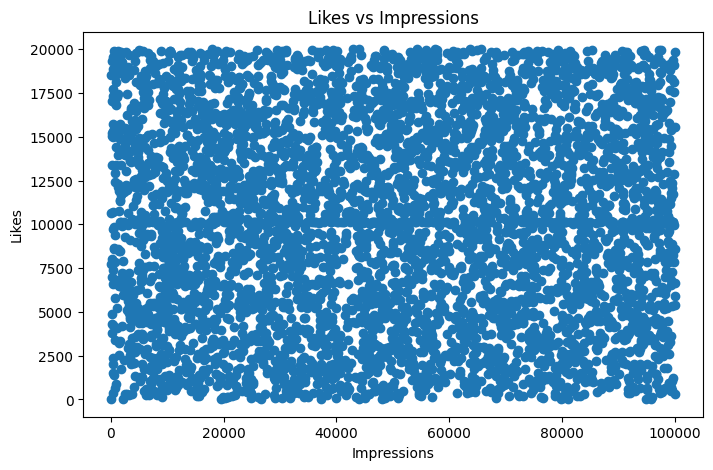

In [279]:
# 1. Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['impression_count'], df['likes'])
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.title('Likes vs Impressions')

plt.show()

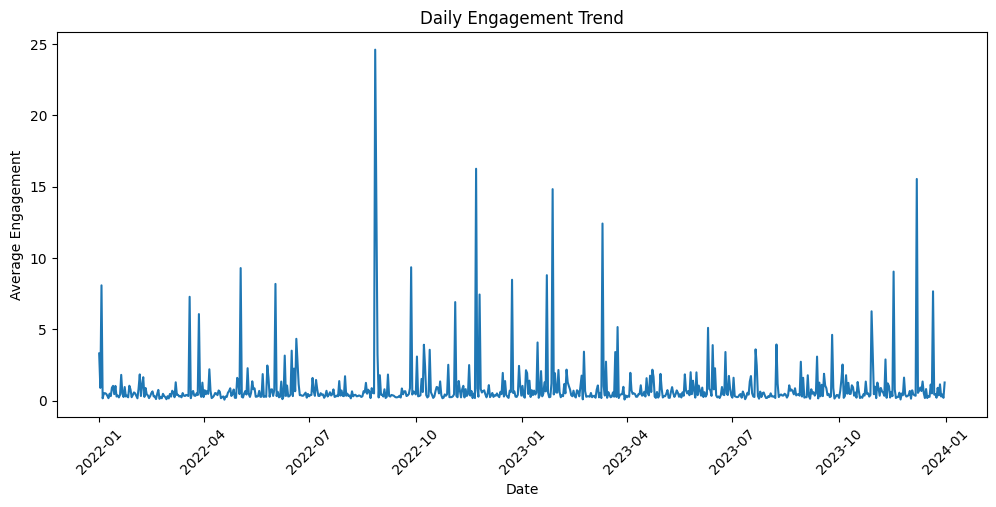

In [280]:
# 2. Line Plot
daily_engagement = df.groupby('posted_at')['engagement_rate'].mean()
plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel('Date')
plt.ylabel('Average Engagement')
plt.title('Daily Engagement Trend')

plt.xticks(rotation=45)

plt.show()

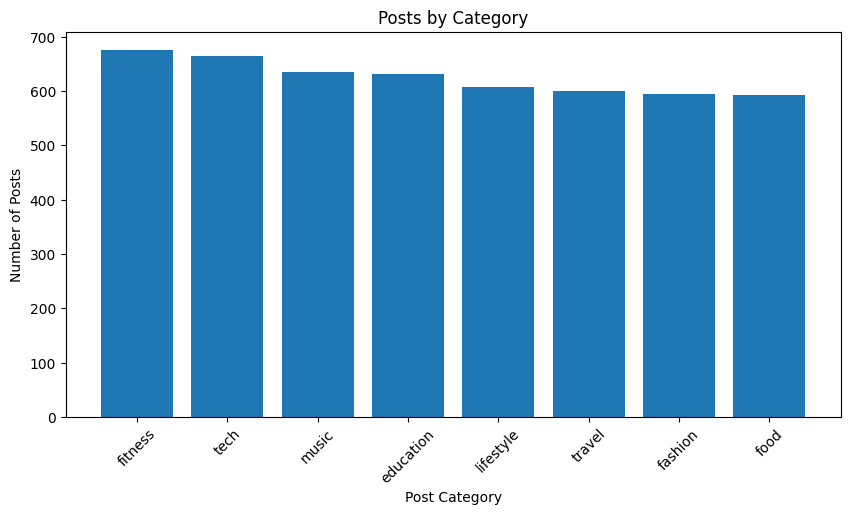

In [281]:
# 3. Bar Chart
category_counts=df['post_category'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')

plt.xticks(rotation=45)

plt.show()

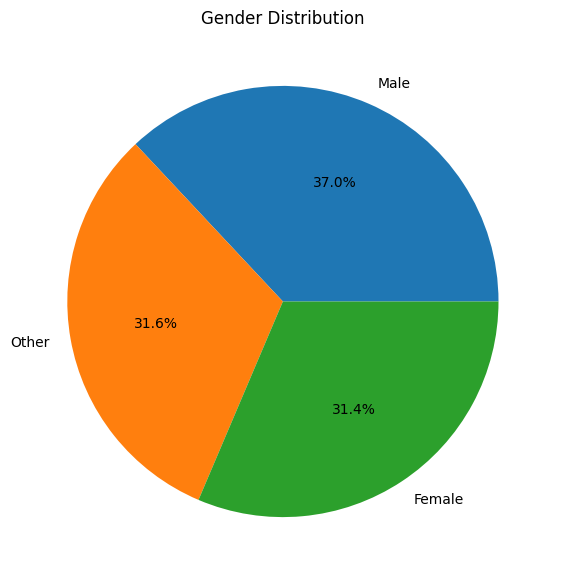

In [282]:
# 4. Pie Chart
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)
plt.title('Gender Distribution')

plt.show()

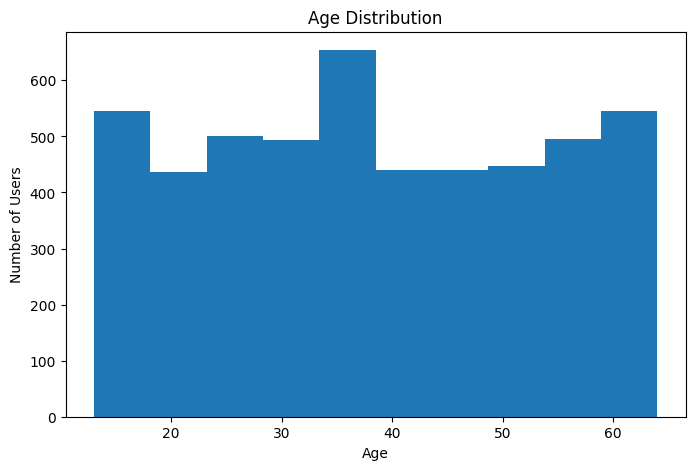

In [283]:
# 5. Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['age'].dropna(), bins=10)
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution')
plt.show()

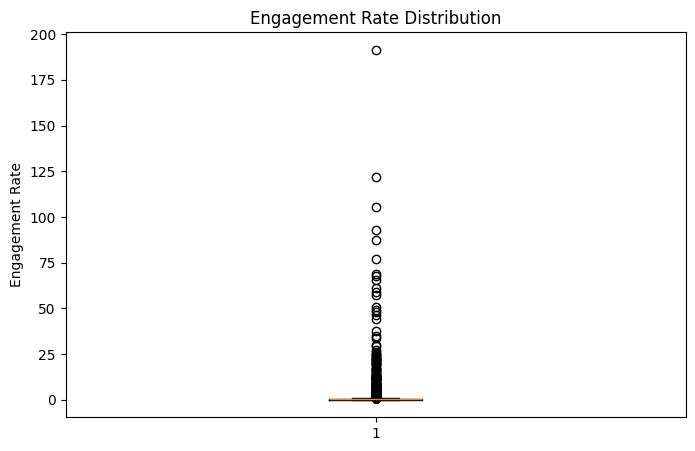

In [284]:
# 6. Box Plot
plt.figure(figsize=(8, 5))
plt.boxplot(df['engagement_rate'].dropna())
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')

plt.show()

Seaborn

In [285]:
import seaborn as sns

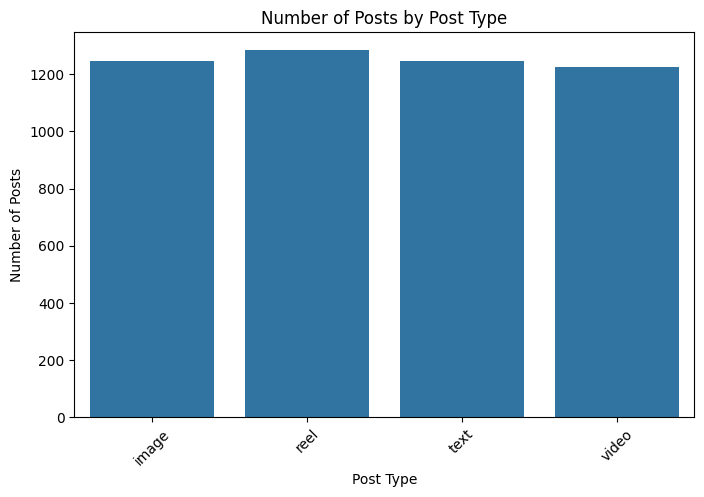

In [286]:
# 1. Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='post_type',data=df)
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Post Type')
plt.xticks(rotation=45)

plt.show()

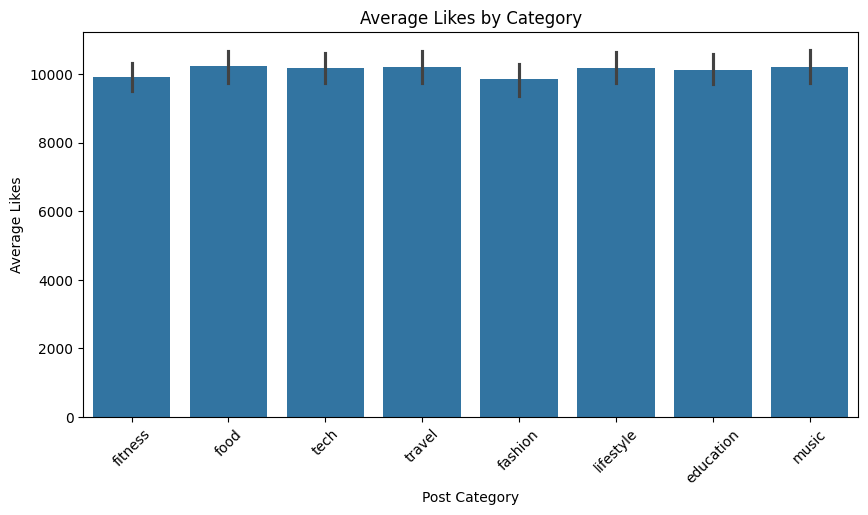

In [287]:
# 2. Bar Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    x='post_category',
    y='likes',
    data=df,
    estimator='mean'
)

plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Category')
plt.xticks(rotation=45)
plt.show()

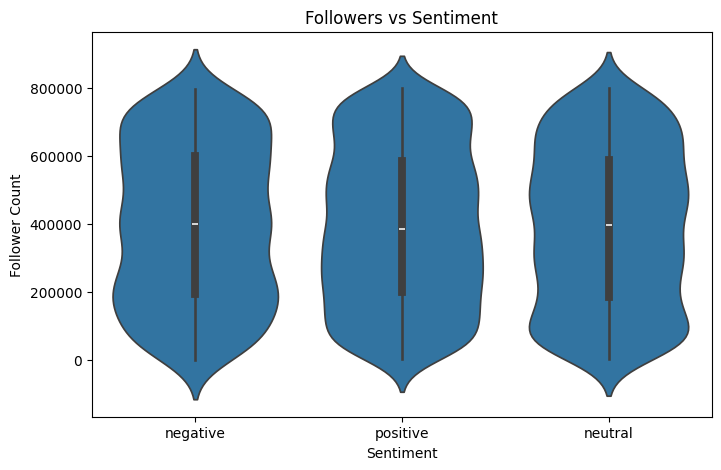

In [288]:
# 3. Violin Plot
plt.figure(figsize=(8, 5))
sns.violinplot(
    x='sentiment',
    y='follower_count',
    data=df
)

plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Followers vs Sentiment')
plt.show()

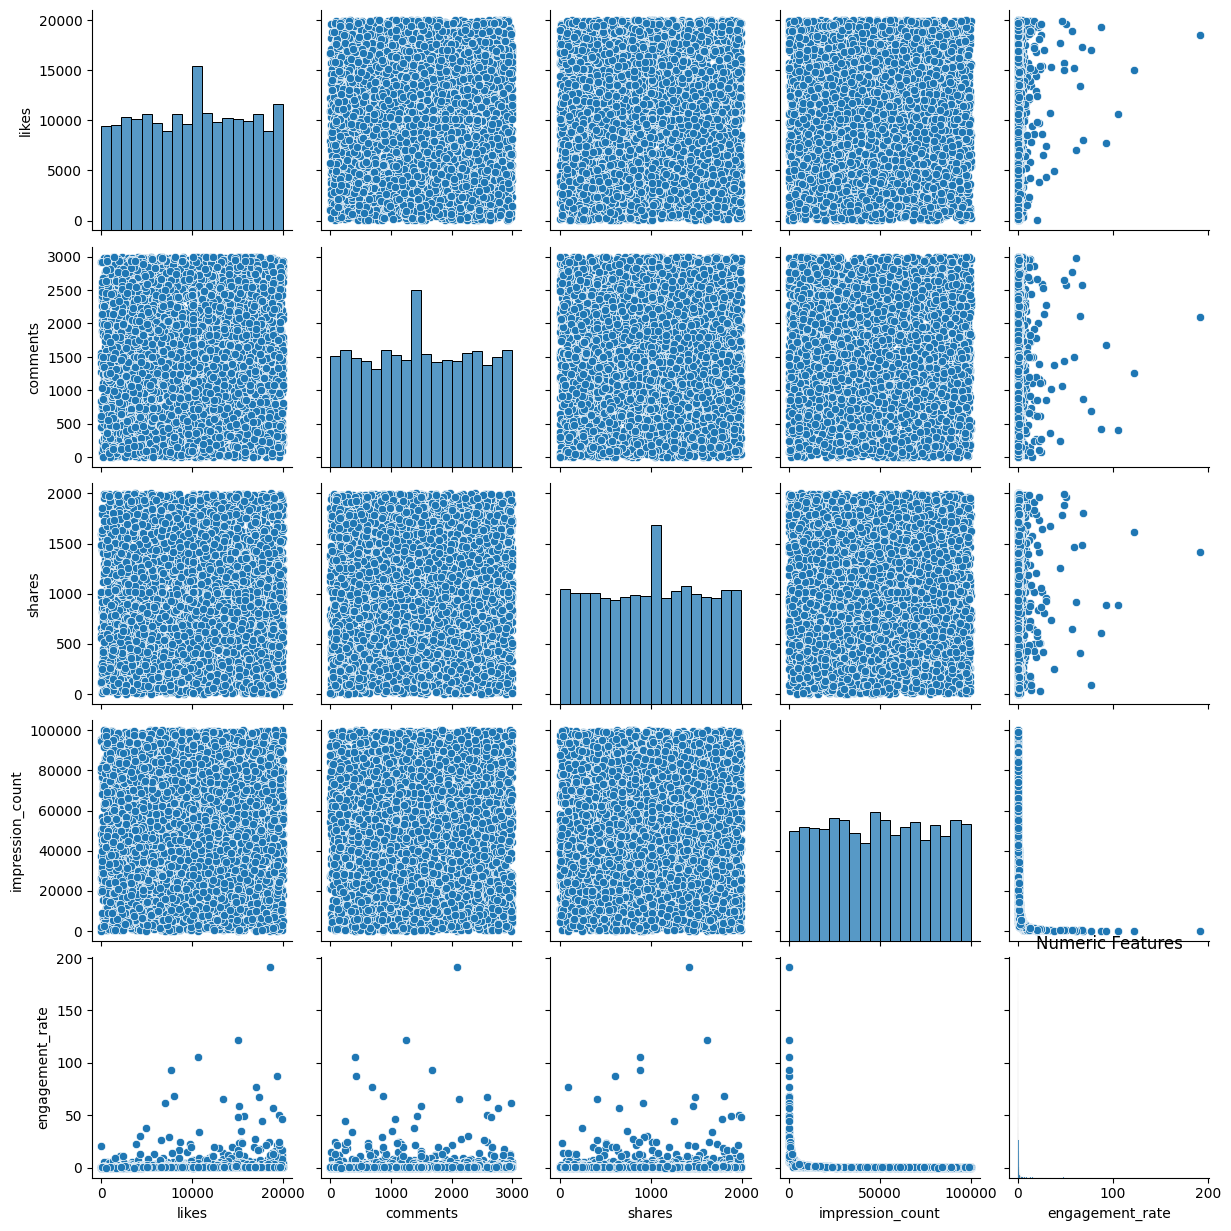

In [289]:
# 4. Pair Plot
pair_columns = [
    'likes',
    'comments',
    'shares',
    'impression_count',
    'engagement_rate'
]
sns.pairplot(df[pair_columns].dropna())
plt.title('Numeric Features')
plt.show()

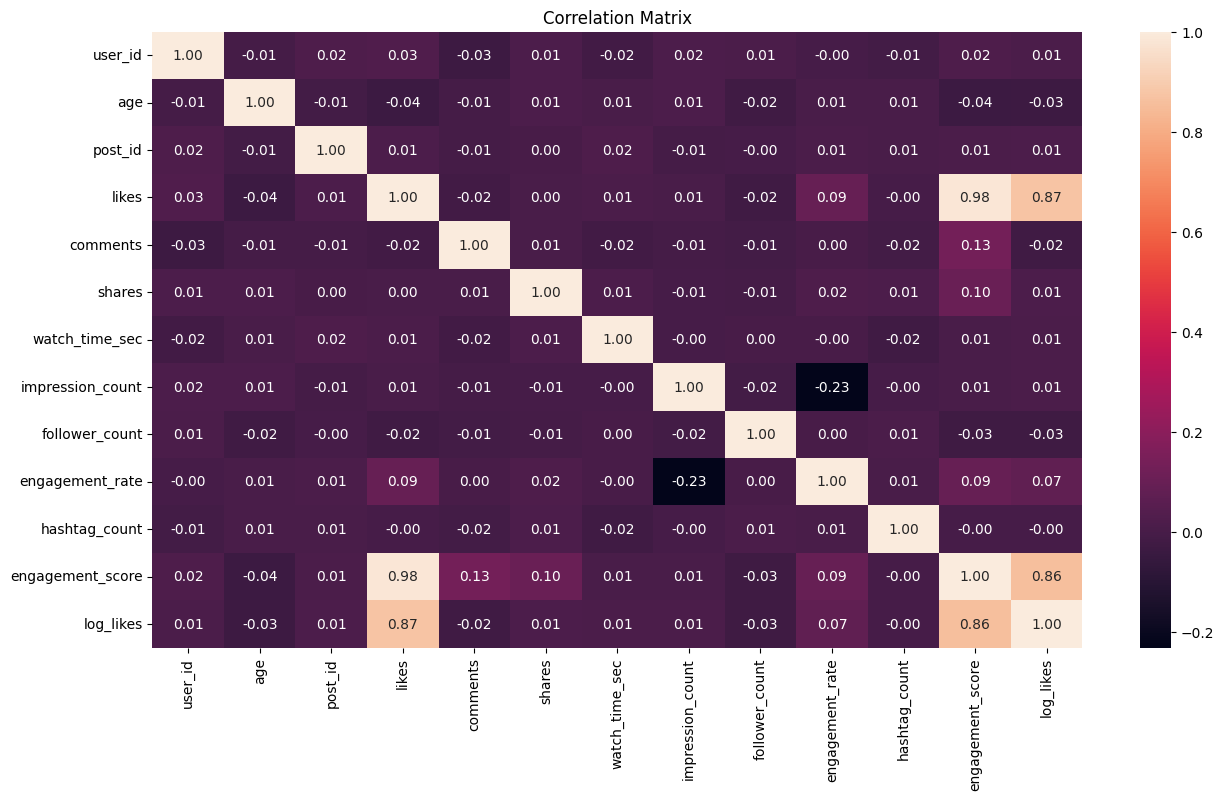

In [290]:
# 5. Heatmap
correlation = df.select_dtypes(include='number').corr()
plt.figure(figsize=(15, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

68.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

69.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

69.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

74.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning:

75.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



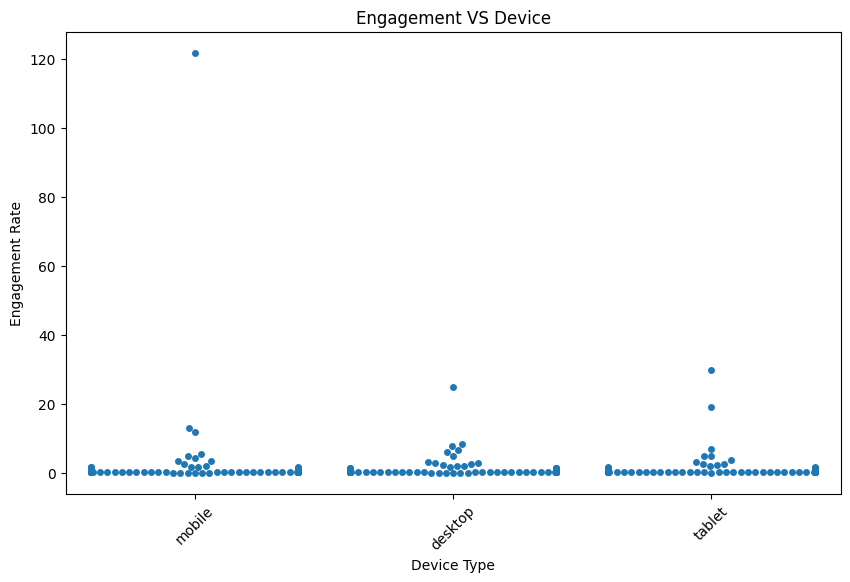

In [291]:
# 6. Swarm Plot
swarm_data=df[['device_type', 'engagement_rate']].dropna().sample(
    n=500,
    random_state=42
)
plt.figure(figsize=(10, 6))
sns.swarmplot(
    data=swarm_data,
    x='device_type',
    y='engagement_rate'
)
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.title('Engagement VS Device')

plt.xticks(rotation=45)

plt.show()

Plotly (Interactive)

In [292]:
import plotly.express as px

In [293]:
# Line Chart
daily_engagement_df = (
    df.groupby('posted_at', as_index=False)['engagement_rate']
    .mean()
)
fig = px.line(
    daily_engagement_df,
    x='posted_at',
    y='engagement_rate',
    title='Interactive Daily Engagement Trend'
)
fig.show()

Final Insights / Findings

In [294]:
# Age group analysis
df['age_group']=pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-60', '60+']
)
age_group_engagement = (
    df.groupby('age_group', observed=True)['engagement_rate']
    .mean()
)
print("Average Engagement Rate by Age Group:")
age_group_engagement

Average Engagement Rate by Age Group:


,engagement_rate
age_group,
Under 18,0.867038
18-25,1.059536
26-35,0.865316
36-45,0.860741
46-60,1.152669
60+,0.801381


In [295]:
# Final Insights
print("FINAL INSIGHTS")
print("="*50)

print("1. Content Performance")
print("Highest performing post type:", post_type_engagement.index[0])
print("Best performing content category:", category_engagement.index[0])
print("Country with highest average engagement rate:", country_engagement.index[0])

print("\n2. User Trends")
print("Age group with highest average engagement rate:", age_group_engagement.idxmax())
print("Verification status with higher average engagement rate:", verified_engagement.idxmax())

print("\n3. Behavioral Insights")
print("Device with highest average watch time:", device_watch_time.index[0])
print("Time-of-day analysis: Not available because posted_at contains only dates, not posting times.")

print("\n4. Sentiment Analysis")
print("Best performing sentiment:", sentiment_engagement.index[0])
print("Negative vs Neutral sentiment performance:")
print(negative_neutral)

FINAL INSIGHTS
1. Content Performance
Highest performing post type: video
Best performing content category: music
Country with highest average engagement rate: brazil

2. User Trends
Age group with highest average engagement rate: 46-60
Verification status with higher average engagement rate: True

3. Behavioral Insights
Device with highest average watch time: mobile
Time-of-day analysis: Not available because posted_at contains only dates, not posting times.

4. Sentiment Analysis
Best performing sentiment: negative
Negative vs Neutral sentiment performance:
           average_engagement_rate  average_likes  average_comments  \
sentiment                                                             
negative                  1.038486   10208.096875       1516.094792   
neutral                   0.991170    9923.194499       1528.404060   

           average_shares  
sentiment                  
negative      1007.307292  
neutral        996.565160  


# **Project Summary**
This analysis examined 5,000 social media engagement records using Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly. The dataset was cleaned by handling missing values, checking duplicates, standardizing categorical values, validating engagement metrics, and extracting hashtag counts.

The analysis found differences in engagement across content types, categories, countries, age groups, account verification status, devices, and sentiment. Video posts had the highest average engagement score among post types, while music was the highest-performing content category. Brazil recorded the highest average engagement rate among the countries in the dataset.

For user trends, the 46–60 age group had the highest average engagement rate among the defined age groups, and verified accounts showed a higher average engagement rate than unverified accounts. For device behavior, mobile users had the highest average watch time.

Sentiment analysis showed that negative posts had the highest average engagement rate. Compared with neutral posts, negative posts also had higher average likes and shares, while neutral posts had slightly higher average comments.

The dataset contains posting dates but does not include the actual time of day, so a reliable analysis of the best time of day for impressions could not be performed. Overall, the analysis demonstrates how social media engagement varies across content, user characteristics, devices, and sentiment.